#### functions and environment

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from PIL import Image
from numpy import concatenate, full
from scipy.stats import gaussian_kde 
from predict_loop_functions import  predict_loop, random_images

#### images and relevant information

In [3]:
folder_id, image_ids, image_stack = random_images(5, path = "C://Users//joshf//Downloads//imagenet-mini")

In [69]:
# save this image stack to computer
np.save('image_stack_july16.npy', image_stack)

# to load
"""
loaded = np.load('image_stack_july16.npy')
"""

"\nloaded = np.load('image_stack_july16.npy')\n"

In [4]:
gray_frames = np.full(shape = (144, 256), fill_value = 128)
# make image id = 0 gray_frames
image_stack[0] = gray_frames
image_stack.shape

(5, 144, 256)

In [10]:
print(f'folder id: {folder_id}; image ids :{image_ids}')

folder id: 909; image ids :[ 1  0 11 13  5]


*for future reference, use these images*

folder id: 909; image ids: [ 1  0 11 13  5] 

Note image with id = 1 will be replaced with gray frames per above

In [7]:
neurons = np.array([1685,368,1571,670,1918,1231,6795,6492,2507,1444,2361,6699,6672,6790,6209,6699,
           1447,5583,2237,2161,7217,5114,4321,4823,6822,5935,823,6501,6819,5782])

#### predictions

In [2]:
# load image stack originally used
image_stack = np.load('image_stack_july16.npy')

In [3]:
dynamic3, dynamic3_mean, dynamic3_var = predict_loop("dynamic", 30, image_stack, 3, [[4,7]], num_frames = 10)

In [13]:
dynamic15, dynamic15_mean, dynamic15_var = predict_loop("dynamic", 30, image_stack, 15, [[4,7]], num_frames = 10)

In [14]:
dynamic30, dynamic30_mean, dynamic30_var = predict_loop("dynamic", 30, image_stack, 30, [[4,7]], num_frames = 10)

In [15]:
constant3, constant3_mean, constant3_var = predict_loop('constant', 30, image_stack, 3, [[4,7]], num_frames = 10)

In [16]:
constant15, constant15_mean, constant15_var = predict_loop('constant', 30, image_stack, 15, [[4,7]], num_frames = 10)

In [17]:
constant30, constant30_mean, constant30_var = predict_loop('constant', 30, image_stack, 30, [[4,7]], num_frames = 10)

In [18]:
stochastic, stochastic_mean, stochastic_var = predict_loop('stochastic binarization', 
                                                           30, image_stack, 0, # sigma trivial here
                                                           [[4,7]], num_frames = 10)

#### load predictions

In [2]:
for noise in ['c3', 'c15', 'c30', 'd3', 'd15', 'd30', 'dbin', 'cbin', 'no_noise']:
    for type_noise in ['_sum', '_mean', '_var', '_labels']:
        file_name = noise + type_noise + '.npy'
        var_name = noise + type_noise
        path = 'saved_inputs_outputs//predictions_july21//' + file_name
        globals()[var_name] = np.load(path)
# load predictions by region
for region in np.unique(d3_labels):
    for noise in ['c3', 'c15', 'c30', 'd3', 'd15', 'd30', 'dbin', 'cbin', 'no_noise']:
        for type_noise in ['_sum', '_mean', '_var']:
            file_name = noise + type_noise + '_r' + str(region) +  '.npy'
            path = 'saved_inputs_outputs//predictions_july21//' + file_name
            array_name = noise + type_noise + '_r' + str(region)
            globals()[array_name] = np.load(path)

#### 30 random neurons from each region

In [5]:
# region 1
r1_randoms = [2322, 3279, 4060, 1756,  146, 4441, 3978, 2034, 5025, 3515, 3534,
       2167, 2310, 1837, 3864, 2529, 4127, 2325, 4791,  314, 3371, 1857,
       1095, 1917, 3097, 1722, 4344, 3627, 3930, 3459]

In [6]:
# region 2
r2_randoms = [958, 907, 514, 432, 594, 385, 184, 368, 525, 351, 302, 551, 550,
       575, 375, 719, 242, 613, 789, 872, 340, 402, 397, 643, 255, 928,
       471, 894, 281, 523]

In [7]:
# region 3
r3_randoms = [279, 337, 208, 128,  46, 115, 248, 197,  52, 269,  37, 364, 340,
       203,  36, 153,  84, 278,  71, 115,  24,  78, 138,  38,  22,  17,
        89, 349, 178, 332]

In [8]:
# region 4
r4_randoms = [376, 295, 517,  25, 663, 429, 427, 651, 133, 500, 689, 266, 470,
       424,  90, 560, 290, 198, 149, 181, 749, 461, 658, 771, 367, 758,
       125, 195, 191,   8]

#### turning curves

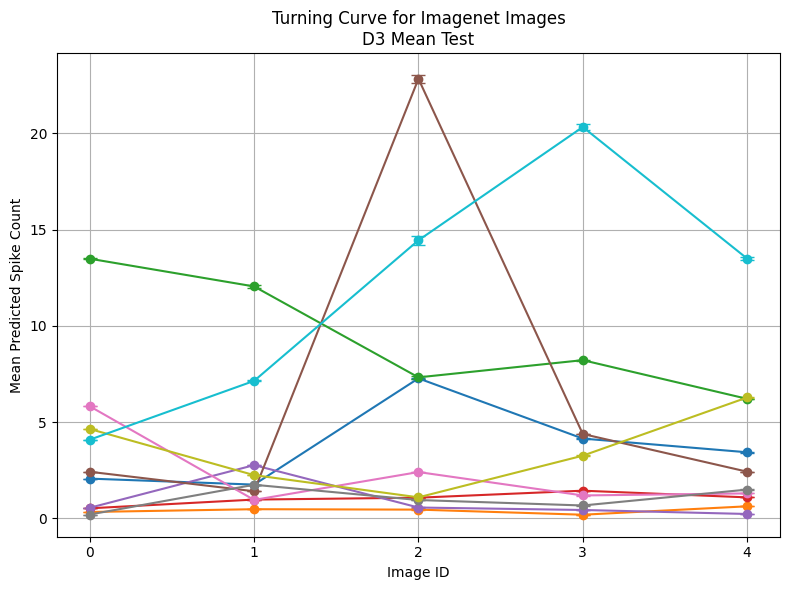

In [85]:
turning_curve(dynamic3, "D3 Mean Test", neurons[:10])

#### turning curves - July 31

In [25]:
def four_turning_curves(arrays: list | np.ndarray, main_title: str, titles: list, ten_neurons: list = [i for i in range(10)]):
    """
    Parameters
    ----------
    arrays: list
        list of output arrys to plot (sum arrays from predict loop)
    main_title: str
        main title at top of plot
    titles: list
        list of corresponding titles for each plot
    ten_neurons: list
        list of ten neurons to use, defaults to first ten 
    """
    fig, axes = plt.subplots(2, 2, figsize=(10, 10), sharex=True)
    image_ids = np.array([i for i in range(5)], dtype=int)
    fig.text(0.5, 1.02, main_title, ha='center', va='top', fontsize=12, fontweight = 'bold', bbox=dict(facecolor='white'))

    for i in range(2):
        for j in range(2):
            idx = i * 2 + j
            ax = axes[i,j]
            
            mean_array = np.mean(arrays[idx], axis=1) 
            variance = np.var(arrays[idx], axis=1)
            std_dev = np.sqrt(variance)

            for neuron in ten_neurons:
                print(neuron)
                neuron_predictions = mean_array[:, neuron]
                ax.errorbar(image_ids, neuron_predictions, yerr=std_dev[:, neuron],
                            marker='o', linestyle='-', capsize=5)

            ax.set_title(f"{titles[idx]}", fontsize=10)
            ax.set_ylabel("Mean Predicted Spike Count")
            ax.xaxis.set_major_locator(MultipleLocator(1))
            ax.grid(True)
    plt.xlabel('Image ID')
    plt.tight_layout()
    plt.show()

In [23]:
dr1_main_title = 'Region: 1\nDynamic Noise'
dr1_titles = ['No Noise', 'Sigma=15', 'Sigma=30', 'Stochastic Binarization']
dr1_arrays = [no_noise_sum_r1, d15_sum_r1, d30_sum_r1, dbin_sum_r1]

0
1
2
3
4
5
6
7
8
9
0
1
2
3
4
5
6
7
8
9
0
1
2
3
4
5
6
7
8
9
0
1
2
3
4
5
6
7
8
9


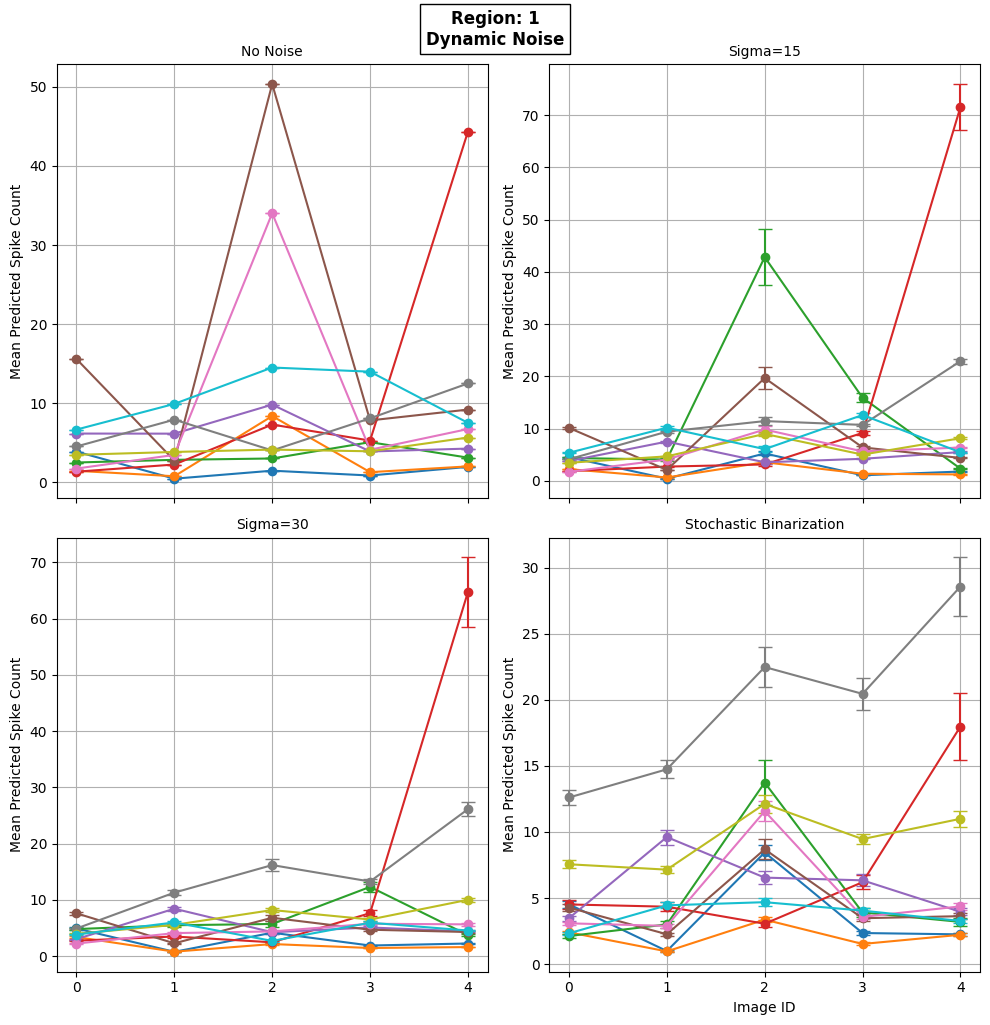

In [26]:
four_turning_curves(dr1_arrays, dr1_main_title, dr1_titles)